# **British Airways Flight Booking Prediction**

Predicting customer booking behavior to enable proactive customer acquisition strategies.

# **STAGE 0: BUSINESS UNDERSTANDING**

## Problem Statement

British Airways faces challenges in customer acquisition, with traditional reactive approaches becoming less effective in today's digital marketplace. With customers having access to extensive information online, waiting for customers to make bookings at the airport is too late. The airline needs a proactive approach to identify and target potential customers before they make their travel decisions, requiring data-driven predictive capabilities to understand customer booking behavior in advance.

## Goals

- **Enhanced customer acquisition**: Develop machine learning models to predict customer booking likelihood, enabling proactive targeting of potential customers. (**MAIN**)
- **Improved business intelligence**: Understand factors influencing customer booking decisions to optimize marketing strategies. (**SECONDARY**)

## Business Metrics

| Metric | Description | Type |
|--------|-------------|------|
| **Customer Acquisition Rate** | The rate at which the airline acquires new customers who book flights or holidays | **MAIN** |
| **Model Predictive Power** | Evaluation metrics (accuracy, precision, recall) demonstrating the model's ability to identify potential customers | **MAIN** |

## Objectives

The ultimate goal of this project is to create a machine learning model that can:

- Accurately predict which customers are likely to book flights or holidays
- Identify key variables that influence booking decisions
- Provide actionable insights to improve customer acquisition strategies before customers embark on their holidays

# **STAGE 1: EXPLORATORY DATA ANALYSIS (EDA)**

## Project Setup

In [27]:
import os
import sys
from pathlib import Path

# Change working directory (for I/O operations)
os.chdir(Path.cwd())

In [28]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Settings
sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)

## Data Understanding & Initial Transformation

In [29]:
# Read data
df_raw = pd.read_csv('data/customer_booking.csv', encoding='Latin1')

# Create a copy of the dataframe
df = df_raw.copy()

Let's first do a quick jump into something that quite interesting here that is the `route` and `booking_origin` columns. Because we can see that the `route` have AKLDEL which is Auckland - Delhi code but booking_origin which is their country could either be New Zealand or India, that means there could be 2 cases here: 

1. Passenger could be departing from their home country (booking_origin matches origin airport country)

2. Passenger returning to their home country (booking_origin matches destination airport country)

In [30]:
# Filter based on both route and booking_origin
df.loc[df['route'].isin(['AKLDEL', 'DELAKL'])]

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0
5,1,Internet,RoundTrip,3,48,20,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
6,3,Internet,RoundTrip,201,33,6,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
7,2,Internet,RoundTrip,238,19,14,Mon,AKLDEL,India,1,0,1,5.52,0
8,1,Internet,RoundTrip,80,22,4,Mon,AKLDEL,New Zealand,0,0,1,5.52,0
9,1,Mobile,RoundTrip,378,30,12,Sun,AKLDEL,India,0,0,0,5.52,0


Turns out there is a new case which is the booking_origin country is United Kingdom. Since our knowledge about this dataset is very limited, it's hard to identify the source of this kind of anomaly, so for further in the project we would just go with assumption that the **booking_origin column means where the user did the transaction, they could be buying it for themself or for other like family member or something**. For now, we wont do much analysis that utilizes these 2 columns, so we will just extract the International Air Transport Association (IATA) code for now.

In [31]:
# Quick Feature Engineering: Extract airport codes from route
df['origin_airport'] = df['route'].str[:3]
df['destination_airport'] = df['route'].str[3:]

# Check the extracted codes
print("Origin airports:", df['origin_airport'].nunique())
print("Destination airports:", df['destination_airport'].nunique())

Origin airports: 85
Destination airports: 64


In [32]:
# Checking shape of dataframe
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 50000
Number of columns: 16


In [33]:
# Check data information using utility function
from utils import check_data_information

info_df = check_data_information(df, df.columns.tolist())
display(info_df)

,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,num_passengers,int64,0,0.0,0,0.00,0,0.0,0,0,719,9,0.0002,"2, 1, 3, 4, 6"
1,sales_channel,str,0,0.0,0,0.00,0,0.0,0,0,719,2,0.0000,"Internet, Mobile"
2,trip_type,str,0,0.0,0,0.00,0,0.0,0,0,719,3,0.0001,"RoundTrip, CircleTrip, OneWay"
3,purchase_lead,int64,0,0.0,370,0.74,0,0.0,0,0,719,470,0.0094,"262, 112, 243, 96, 68"
4,length_of_stay,int64,0,0.0,9,0.02,0,0.0,0,0,719,335,0.0067,"19, 20, 22, 31, 48"
5,flight_hour,int64,0,0.0,1539,3.08,0,0.0,0,0,719,24,0.0005,"7, 3, 17, 4, 15"
6,flight_day,str,0,0.0,0,0.00,0,0.0,0,0,719,7,0.0001,"Sat, Wed, Thu, Mon, Sun"
7,route,str,0,0.0,0,0.00,0,0.0,0,0,719,799,0.0160,"AKLDEL, AKLHGH, AKLHND, AKLICN, AKLKIX"
8,booking_origin,str,0,0.0,0,0.00,0,0.0,0,0,719,104,0.0021,"New Zealand, India, United Kingdom, China, Sou..."
9,wants_extra_baggage,int64,0,0.0,16561,33.12,0,0.0,0,0,719,2,0.0000,"1, 0"


In [34]:
# Drop duplicated values
df = df.drop_duplicates()
print(f'Rows after removing duplicates: {df.shape[0]}')

Rows after removing duplicates: 49281


### Feature Information - Flight Booking Dataset

| **Feature Name** | **Description** | **Data Type** | **Specific Data Type** |
|------------------|----------------|--------------|----------------------|
| `num_passengers` | Number of passengers travelling | Numerical | Discrete |
| `sales_channel` | Sales channel booking was made on (Internet, Mobile) | Categorical | Nominal |
| `trip_type` | Trip type (Round Trip, One Way, Circle Trip) | Categorical | Nominal |
| `purchase_lead` | Number of days between travel date and booking date | Numerical | Discrete |
| `length_of_stay` | Number of days spent at destination | Numerical | Discrete |
| `flight_hour` | Hour of flight departure | Numerical | Discrete |
| `flight_day` | Day of week of flight departure | Categorical | Nominal |
| `route` | Origin -> destination flight route | Categorical | Nominal |
| `booking_origin` | Country from where booking was made | Categorical | Nominal |
| `wants_extra_baggage` | If the customer wanted extra baggage (1=Yes, 0=No) | Categorical | Binary |
| `wants_preferred_seat` | If the customer wanted a preferred seat (1=Yes, 0=No) | Categorical | Binary |
| `wants_in_flight_meals` | If the customer wanted in-flight meals (1=Yes, 0=No) | Categorical | Binary |
| `flight_duration` | Total duration of flight (in hours) | Numerical | Continuous |
| `booking_complete` | Flag indicating if customer completed booking (1=Yes, 0=No) | Categorical | Binary |
| `origin_airport` | Airport code for departure location | Categorical | Nominal |
| `destination_airport` | Airport code for arrival location | Categorical | Nominal |

**Dataset Summary:**
- Total features: 16
- Target variable: `booking_complete` (binary classification target)
- Contains 640 null values (0.07% of the dataset)
- Dataset includes flight booking information with customer preferences, timing details, and route information
- Features include both numerical (discrete and continuous) and categorical variables

**Key Insights:**
- The dataset captures the entire booking journey from selection to completion
- Contains customer preference information (extra baggage, preferred seats, meals)
- Includes temporal data (purchase lead time, flight hour, day of week)
- Geographic information represented through routes and booking origin
- Binary target variable indicates whether bookings were completed or abandoned

In [35]:
# Change the data type for flight amenity preference columns
df['wants_extra_baggage'] = df['wants_extra_baggage'].astype('str')
df['wants_preferred_seat'] = df['wants_preferred_seat'].astype('str')
df['wants_in_flight_meals'] = df['wants_in_flight_meals'].astype('str')

In [36]:
# Group columns by data type
nums_cols = ['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']
cats_cols = ['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin', 
             'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals',
             'origin_airport', 'destination_airport']

target = "booking_complete"
target_label = "booking_complete_label"

In [37]:
# Create target label for visualization
df[target_label] = df[target].map({0: 'No Booking', 1: 'Completed Booking'})

## Univariate Analysis

**Purpose:** Understand distributions and basic statistics of features before splitting.

### Numerical Features

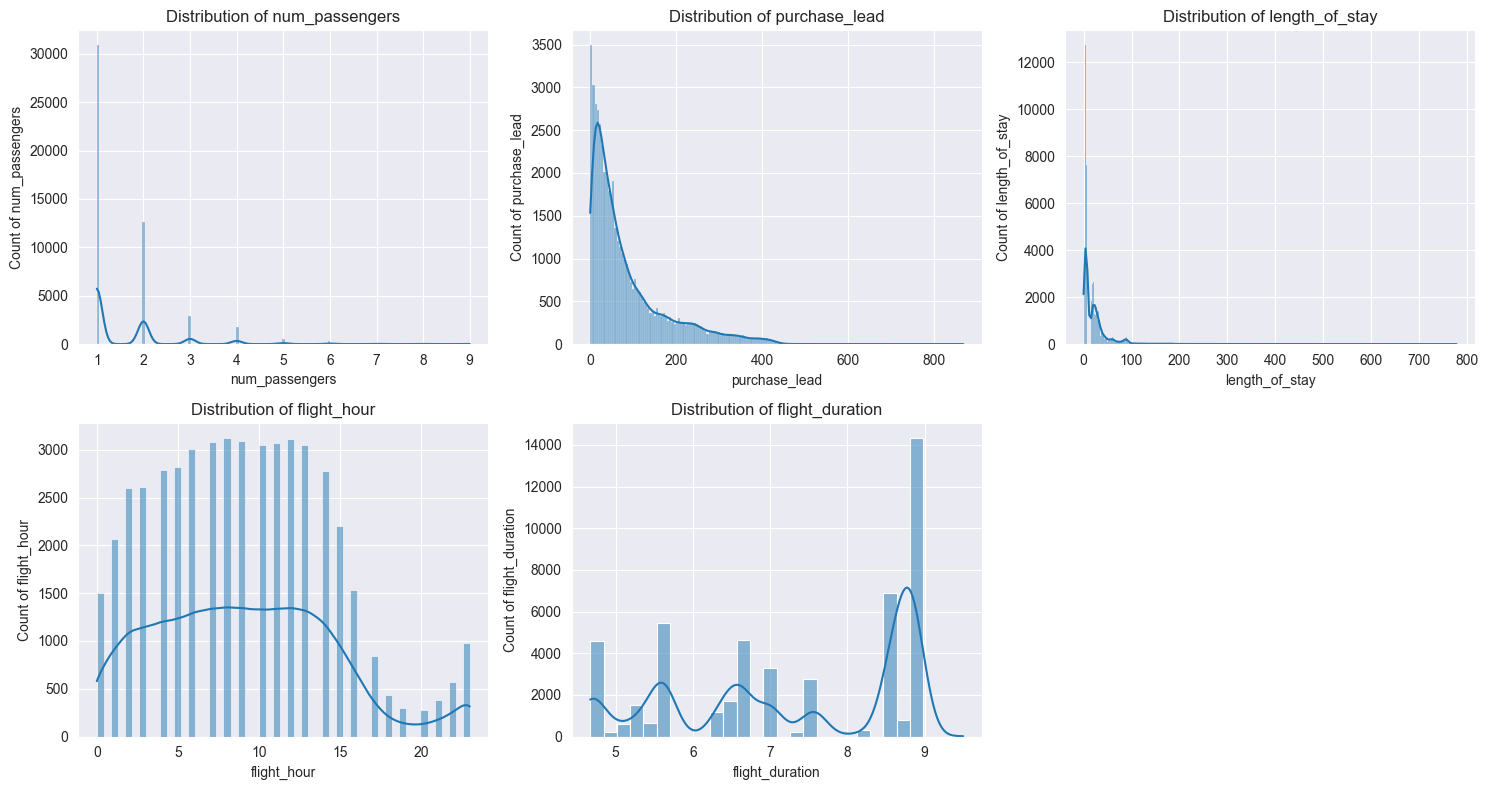

,Feature,overall_count,overall_mean,overall_std,overall_min,overall_25%,overall_50%,overall_75%,overall_max,overall_range,overall_IQR,overall_CV,overall_skewness,overall_kurtosis
0,num_passengers,49281.0,1.590187,1.016538,1.00,1.00,1.00,2.00,9.0,8.00,1.00,63.925663,2.688013,10.074914
1,purchase_lead,49281.0,84.723281,90.410229,0.00,21.00,51.00,115.00,867.0,867.00,94.00,106.712380,1.656766,2.501201
2,length_of_stay,49281.0,23.053976,33.832149,0.00,5.00,17.00,28.00,778.0,778.00,23.00,146.751906,5.296315,49.360070
3,flight_hour,49281.0,9.070676,5.413099,0.00,5.00,9.00,13.00,23.0,23.00,8.00,59.676906,0.398129,-0.299949
4,flight_duration,49281.0,7.279974,1.496390,4.67,5.62,7.57,8.83,9.5,4.83,3.21,20.554880,-0.362099,-1.372566


,Column Name,Mean,Median,Mode,Skewness,Kurtosis,Skewness Type,Kurtosis Type
0,num_passengers,1.590,1.00,1.00,2.688,10.075,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
1,purchase_lead,84.723,51.00,1.00,1.657,2.501,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
2,length_of_stay,23.054,17.00,6.00,5.296,49.360,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
3,flight_hour,9.071,9.00,8.00,0.398,-0.300,Slightly Positively Skewed,Mesokurtic (Normal-like)
4,flight_duration,7.280,7.57,8.83,-0.362,-1.373,Slightly Negatively Skewed,Platykurtic (Light-tailed)
5,booking_complete,0.150,0.00,0.00,1.961,1.844,Highly Positively Skewed,Leptokurtic (Heavy-tailed)


In [38]:
# Checking the distribution and statistical summary of the numerical values
from utils import plot_dynamic_hisplots_kdeplots, describe_numerical_combined, identify_distribution_types

plot_dynamic_hisplots_kdeplots(df=df, col_series=nums_cols, ncols=3, figsize=(15, 8))

# Display the overall statistics for numerical columns
numerical_summary = describe_numerical_combined(df, nums_cols)
display(numerical_summary)

# Display the distribution types
result = identify_distribution_types(df, df.select_dtypes('number').columns.tolist())
display(result)

### Categorical Features

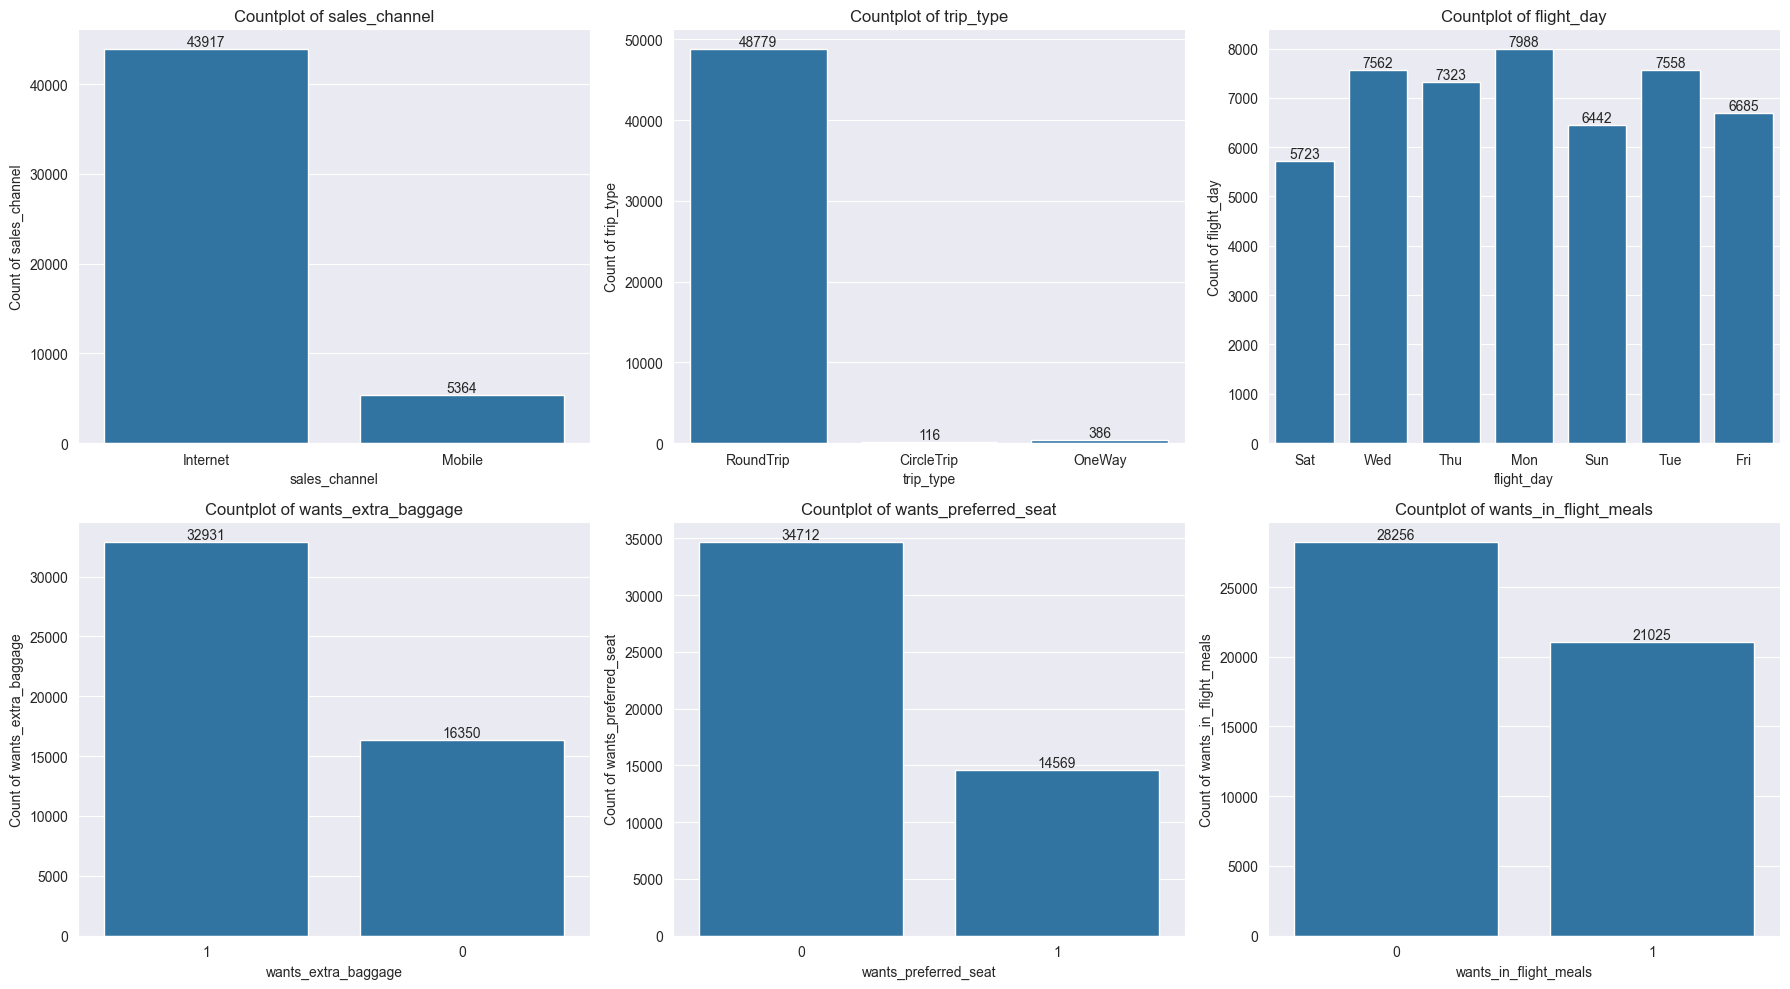

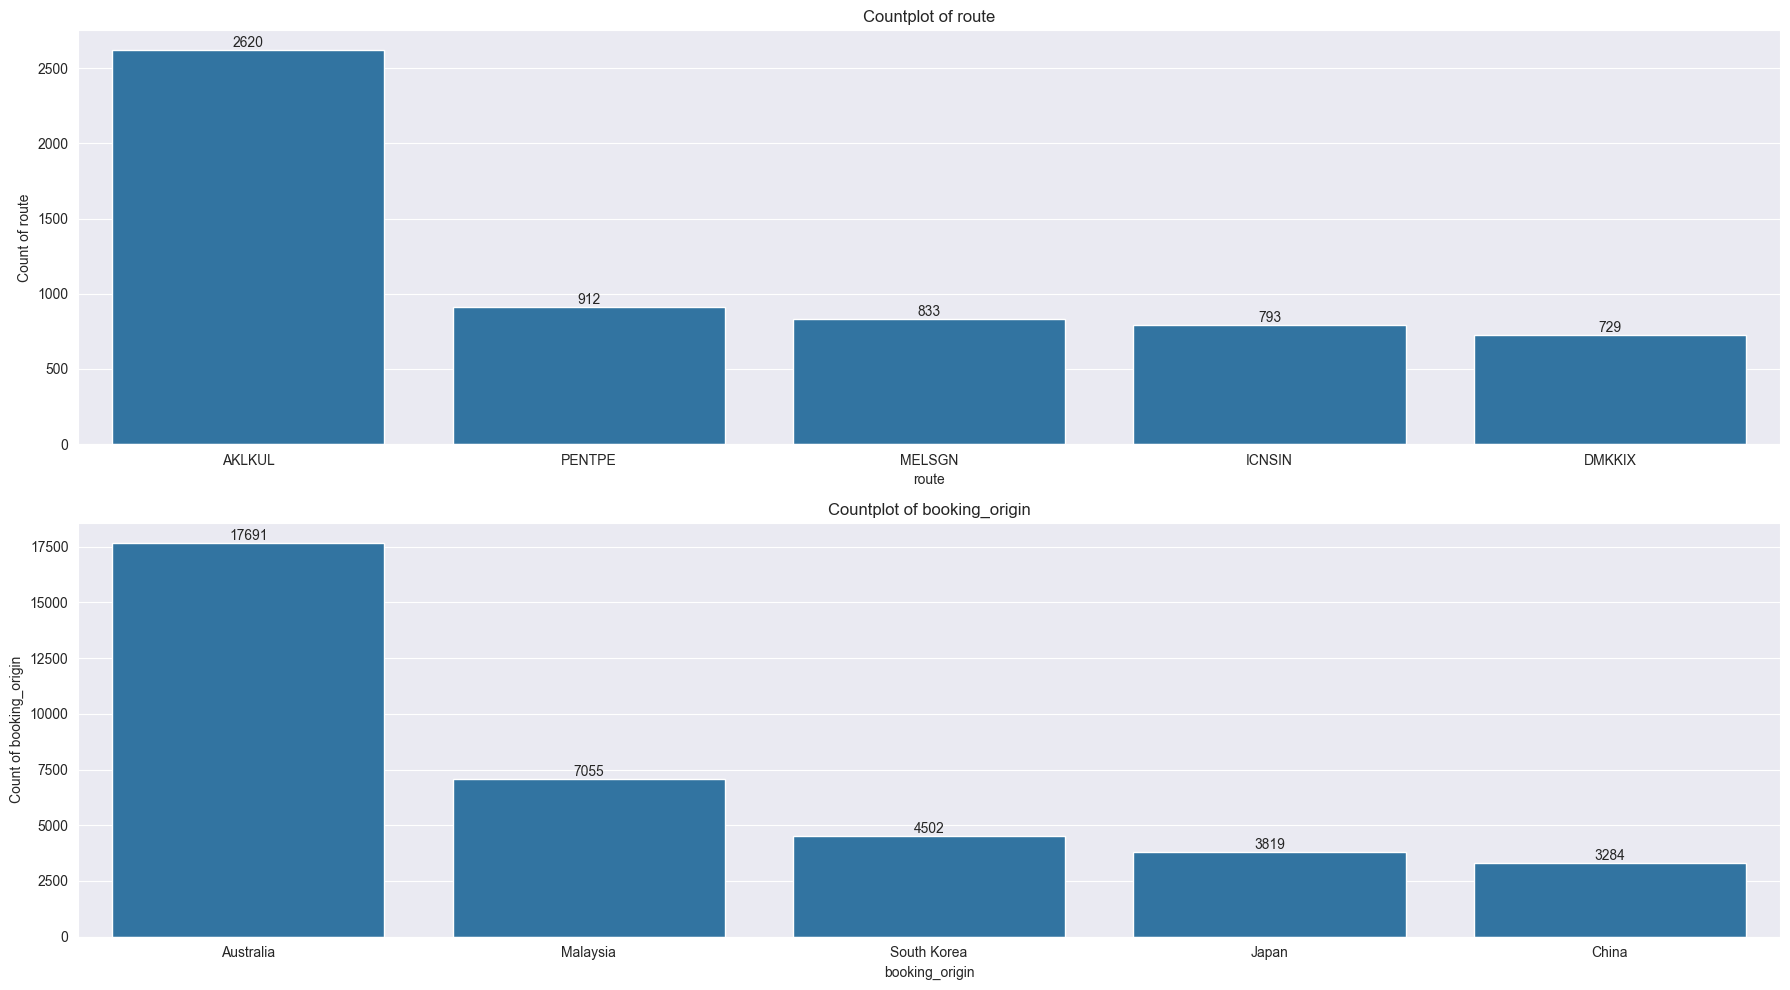

,Feature,overall_count,overall_unique,overall_top,overall_freq,overall_bottom,overall_freq_bottom,overall_top_percentage,overall_bottom_percentage,overall_n_categories
0,sales_channel,49281,2,Internet,43917,Mobile,5364,89.12,10.88,2
1,trip_type,49281,3,RoundTrip,48779,CircleTrip,116,98.98,0.24,3
2,flight_day,49281,7,Mon,7988,Sat,5723,16.21,11.61,7
3,route,49281,799,AKLKUL,2620,AKLHGH,1,5.32,0.00,799
4,booking_origin,49281,104,Australia,17691,Slovakia,1,35.90,0.00,104
5,wants_extra_baggage,49281,2,1,32931,0,16350,66.82,33.18,2
6,wants_preferred_seat,49281,2,0,34712,1,14569,70.44,29.56,2
7,wants_in_flight_meals,49281,2,0,28256,1,21025,57.34,42.66,2
8,origin_airport,49281,85,DMK,3698,BTJ,1,7.50,0.00,85
9,destination_airport,49281,64,SYD,6543,PDG,1,13.28,0.00,64


In [41]:
# Checking the distribution and statistical summary of categorical values
from utils import describe_categorical_combined, plot_dynamic_countplot

# Define categorical columns with few unique values for visualization
cats_few = ['sales_channel', 'trip_type', 'flight_day', 'wants_extra_baggage', 
            'wants_preferred_seat', 'wants_in_flight_meals']

# Define categorical columns with high cardinality categorical features (top 10 only)
cats_many = ['route', 'booking_origin']

plot_dynamic_countplot(df=df, col_series=cats_few, ncols=3, figsize=(18, 10))
plot_dynamic_countplot(df=df, col_series=cats_many, ncols=1, figsize=(18, 10),
     order=[df[cat].value_counts().iloc[:5].index.tolist() for cat in cats_many])

# Display statistics for categorical columns
categorical_summary = describe_categorical_combined(df, cats_cols)
display(categorical_summary)

### Target Distribution

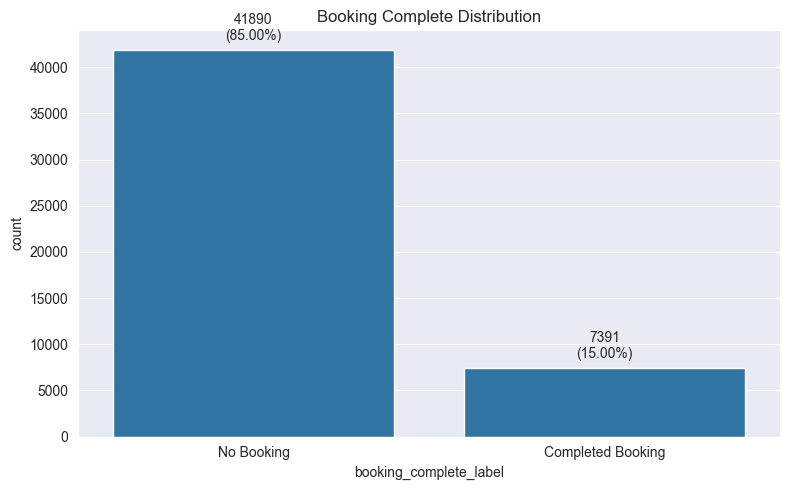


Class imbalance ratio: 5.67:1


In [42]:
# Visualize target distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x=target_label)

total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{int(count)}\n({percentage:.2f}%)', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.title('Booking Complete Distribution')
plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio: {df[target].value_counts()[0] / df[target].value_counts()[1]:.2f}:1")

## Bivariate/Multivariate Analysis

In [ ]:
# Correlation heatmap of numerical features
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df[nums_cols + [target]].corr(method='spearman'), dtype=bool))
sns.heatmap(data=df[nums_cols + [target]].corr(method='spearman'), 
            mask=mask, cmap='coolwarm', annot=True, fmt='.2f', vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Countplot with hue for categorical features vs target
plot_dynamic_countplot(df=df, col_series=cats_few, ncols=3, hue=target_label, figsize=(18, 12))

# **STAGE 2: DATA SPLITTING (CRITICAL STEP)**

**Splitting BEFORE preprocessing prevents data leakage:**

1. **Outlier Removal:** If we calculate IQR on full dataset, test set statistics influence training decisions
2. **Feature Encoding:** Category frequencies from test set shouldn't inform training
3. **Feature Selection:** Correlation/importance scores using test data = cheating
4. **Scaling:** Must come after split, fitted on training data only

**Principle:** Test set should be completely unseen until final evaluation.

## Split Strategy: 75% Train, 20% Validation, 5% Test

- **Training (75%):** Fit all preprocessing steps and train models
- **Validation (20%):** Tune hyperparameters and select best model
- **Test (5%):** Final evaluation only, never touched during development

**Note:** We use stratified sampling to preserve the class imbalance ratio across all splits.

In [ ]:
from sklearn.model_selection import train_test_split

# Drop derived columns not needed for modeling
cols_to_drop = ['origin_airport', 'destination_airport', target_label]

# Separate features and target
X_raw = df.drop(columns=[target] + cols_to_drop)
y_raw = df[target]

# First split: 75% train, 25% temp (which will become val + test)
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_raw, y_raw, 
    test_size=0.25, 
    random_state=42,
    stratify=y_raw  # Preserve class imbalance
)

# Second split: Split temp into 80% validation (20% of original) and 20% test (5% of original)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw, y_temp_raw, 
    test_size=0.2, 
    random_state=42,
    stratify=y_temp_raw
)

# Display split sizes
total_samples = len(X_raw)
print(f"Total samples: {total_samples:,}")
print(f"\nTraining set: {len(X_train_raw):,} samples ({len(X_train_raw)/total_samples*100:.1f}%)")
print(f"Validation set: {len(X_val_raw):,} samples ({len(X_val_raw)/total_samples*100:.1f}%)")
print(f"Test set: {len(X_test_raw):,} samples ({len(X_test_raw)/total_samples*100:.1f}%)")

# Check target distribution across splits
print(f"\nTarget distribution in Training set:")
print(y_train_raw.value_counts(normalize=True))
print(f"\nTarget distribution in Validation set:")
print(y_val_raw.value_counts(normalize=True))
print(f"\nTarget distribution in Test set:")
print(y_test_raw.value_counts(normalize=True))

# **STAGE 3: DATA PREPROCESSING (TRAIN + VAL ONLY)**

From this point forward:
- All preprocessing is **fitted on training data only**
- Validation and test sets are **transformed** using training statistics
- We never look at test set until final evaluation

## Outlier Detection and Removal

**Why after split?** IQR thresholds calculated from training data only.

In [ ]:
from utils import filter_outliers, plot_dynamic_boxplots_violinplots

# Combine train features and target for outlier detection
df_train = pd.concat([X_train_raw, y_train_raw], axis=1)

# Check outliers on TRAINING data only
outlier_summary = filter_outliers(df_train, columns=nums_cols, threshold=1.5, detect_only=True)
display(outlier_summary)

In [ ]:
# Remove outliers from TRAINING data and get IQR limits
# Step 1: Get IQR limits from training data
train_outlier_summary = filter_outliers(df_train, columns=nums_cols, method='iqr', threshold=1.5, detect_only=True, verbose=False)

# Step 2: Remove outliers from training data
df_train_clean = filter_outliers(df_train, columns=nums_cols, method='iqr', threshold=1.5, detect_only=False)
X_train_clean = df_train_clean.drop(columns=[target])
y_train_clean = df_train_clean[target]

# Step 3: Apply SAME IQR limits to validation data
def filter_using_training_limits(data, columns, limits_df):
    """Filter outliers using pre-computed IQR limits from training data."""
    mask = pd.Series([True] * len(data), index=data.index)
    
    for _, row in limits_df.iterrows():
        col = row['Column Name']
        if col in columns and col in data.columns:
            lower = row['Lower Limit']
            upper = row['Upper Limit']
            col_mask = (data[col] >= lower) & (data[col] <= upper)
            mask = mask & col_mask
    
    return data[mask]

# Apply to validation
df_val = pd.concat([X_val_raw, y_val_raw], axis=1)
df_val_clean = filter_using_training_limits(df_val, nums_cols, train_outlier_summary)
X_val_clean = df_val_clean.drop(columns=[target])
y_val_clean = df_val_clean[target]

print(f"Training samples after outlier removal: {len(X_train_clean):,}")
print(f"Removed {len(X_train_raw) - len(X_train_clean):,} outlier samples from training set")
print(f"\nValidation samples after applying training limits: {len(X_val_clean):,}")
print(f"Removed {len(X_val_raw) - len(X_val_clean):,} outlier samples from validation set")
print(f"\nTest set: {len(X_test_raw):,} (unchanged - for final evaluation only)")

## Feature Encoding

**Encoding Strategy:**
- **Label Encoding:** For binary features (sales_channel)
- **Frequency Encoding:** For high cardinality features (route, booking_origin)
- **One-Hot Encoding:** For nominal categories with low cardinality (trip_type, flight_day)

In [ ]:
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce

# Make copies for encoding
X_train_encoded = X_train_clean.copy()
X_val_encoded = X_val_clean.copy()
X_test_encoded = X_test_raw.copy()

# 1. Label Encoding for sales_channel (binary)
le = LabelEncoder()
X_train_encoded['sales_channel'] = le.fit_transform(X_train_encoded['sales_channel'])
X_val_encoded['sales_channel'] = le.transform(X_val_encoded['sales_channel'])
X_test_encoded['sales_channel'] = le.transform(X_test_encoded['sales_channel'])

print(f"Sales channel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

In [ ]:
# 2. Frequency Encoding for high cardinality features
# FIT on training data only
freq_cols = ['route', 'booking_origin']

for col in freq_cols:
    # Calculate frequencies from training data
    freq_map = X_train_encoded[col].value_counts().to_dict()
    
    # Apply to all sets
    X_train_encoded[col] = X_train_encoded[col].map(freq_map)
    X_val_encoded[col] = X_val_encoded[col].map(freq_map).fillna(1)  # Unknown = frequency 1
    X_test_encoded[col] = X_test_encoded[col].map(freq_map).fillna(1)

print(f"Frequency encoding applied to: {freq_cols}")

In [ ]:
# 3. One-Hot Encoding for nominal categories
ohe_cols = ['trip_type', 'flight_day']

# FIT on training data only
for col in ohe_cols:
    # Get dummies for training data
    train_dummies = pd.get_dummies(X_train_encoded[col], prefix=col, drop_first=True)
    
    # Apply to training
    X_train_encoded = pd.concat([X_train_encoded.drop(columns=[col]), train_dummies], axis=1)
    
    # Apply to validation (align columns)
    val_dummies = pd.get_dummies(X_val_encoded[col], prefix=col, drop_first=True)
    val_dummies = val_dummies.reindex(columns=train_dummies.columns, fill_value=0)
    X_val_encoded = pd.concat([X_val_encoded.drop(columns=[col]), val_dummies], axis=1)
    
    # Apply to test (align columns)
    test_dummies = pd.get_dummies(X_test_encoded[col], prefix=col, drop_first=True)
    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)
    X_test_encoded = pd.concat([X_test_encoded.drop(columns=[col]), test_dummies], axis=1)

print(f"One-hot encoding applied to: {ohe_cols}")
print(f"\nEncoded features shape: {X_train_encoded.shape}")

## Feature Selection

In [ ]:
from utils import calculate_correlation_tabular

# Combine train data for correlation analysis
df_train_encoded = pd.concat([X_train_encoded, y_train_clean.reset_index(drop=True)], axis=1)

# Calculate correlation on TRAINING data only
feature_feature_df, feature_target_df = calculate_correlation_tabular(
    df_train_encoded, 
    target_col=target, 
    method='spearman', 
    corr_type='both'
)

In [ ]:
from utils import calculate_feature_importance

# Calculate feature importance using TRAINING data only
feature_importance = calculate_feature_importance(
    X=X_train_encoded, 
    y=y_train_clean.reset_index(drop=True), 
    task='classification', 
    method='mutual_info', 
    k='all'
)

print("Top 15 features by Mutual Information:")
display(feature_importance.head(15))

## Feature Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Select numerical columns for scaling (excluding binary/categorical)
cols_to_scale = ['num_passengers', 'purchase_lead', 'length_of_stay', 
                 'flight_hour', 'flight_duration', 'route', 'booking_origin']

# FIT scaler on TRAINING data only
scaler = MinMaxScaler()
X_train_encoded[cols_to_scale] = scaler.fit_transform(X_train_encoded[cols_to_scale])

# TRANSFORM validation and test using fitted scaler
X_val_encoded[cols_to_scale] = scaler.transform(X_val_encoded[cols_to_scale])
X_test_encoded[cols_to_scale] = scaler.transform(X_test_encoded[cols_to_scale])

print(f"MinMax scaling applied to: {cols_to_scale}")
print(f"\nFinal feature shapes:")
print(f"Training: {X_train_encoded.shape}")
print(f"Validation: {X_val_encoded.shape}")
print(f"Test: {X_test_encoded.shape}")

## Handling Class Imbalance (Training Set Only)

In [ ]:
from imblearn.over_sampling import SMOTE

# Check class distribution before SMOTE
print("Class distribution before SMOTE:")
print(y_train_clean.value_counts(normalize=True))

# Apply SMOTE to training data only
smote = SMOTE(sampling_strategy=0.8, random_state=42)  # 0.8 = 4:5 ratio
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_encoded, y_train_clean)

print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_balanced).value_counts(normalize=True))
print(f"\nTraining samples after SMOTE: {len(X_train_balanced):,}")

# **STAGE 4: MODELING**

## Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

# Train all models
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model
    
print("\nAll models trained successfully!")

## Model Evaluation

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, classification_report, 
                             confusion_matrix)

# Evaluation function
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*50}")
    print(f"Evaluation Results for {model_name}")
    print(f"{'='*50}")
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Booking', 'Completed Booking']))
    
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }

# Evaluate all models on validation set
results = []
for name, model in trained_models.items():
    result = evaluate_model(model, X_val_encoded, y_val_clean, name)
    results.append(result)

In [ ]:
# Create comparison DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('recall', ascending=False)

print("\nModel Comparison (sorted by Recall):")
display(results_df.round(4))

## Feature Importance

In [ ]:
# Get feature importance from best model (assuming tree-based model)
best_model_name = results_df.iloc[0]['model']
best_model = trained_models[best_model_name]

print(f"Best performing model: {best_model_name}")

# Plot feature importance
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': X_train_encoded.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance_df.head(15), x='importance', y='feature')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.tight_layout()
    plt.show()
    
    display(importance_df.head(15))

## Final Test Set Evaluation

In [ ]:
# Evaluate best model on test set (FINAL EVALUATION)
print("FINAL EVALUATION ON TEST SET")
print("="*50)

final_result = evaluate_model(best_model, X_test_encoded, y_test_raw, best_model_name)

# Confusion matrix
y_pred_test = best_model.predict(X_test_encoded)
cm = confusion_matrix(y_test_raw, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Booking', 'Completed Booking'],
            yticklabels=['No Booking', 'Completed Booking'])
plt.title(f'Confusion Matrix - {best_model_name} (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Save Model and Artifacts

In [ ]:
import joblib

# Save the best model
joblib.dump(best_model, 'best_booking_prediction_model.pkl')
joblib.dump(scaler, 'minmax_scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model and preprocessing artifacts saved successfully!")
print(f"\nSaved files:")
print("- best_booking_prediction_model.pkl")
print("- minmax_scaler.pkl")
print("- label_encoder.pkl")